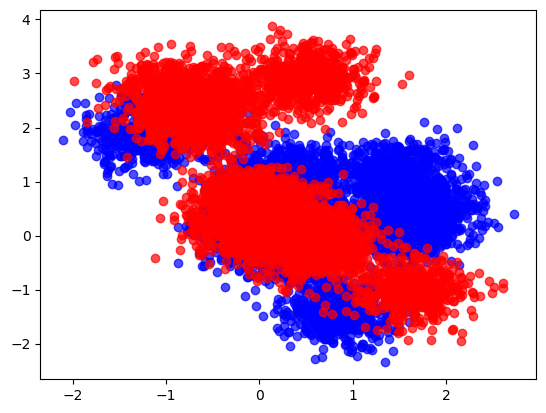

In [23]:
import numpy as np
import matplotlib.pyplot as plt

means_pos=np.random.multivariate_normal([1,0],[[1,0],[0,1]],size=10)
means_neg=np.random.multivariate_normal([0,1],[[1,0],[0,1]],size=10)

pos=[]
neg=[]

for i in range(10):
    pospts=np.random.multivariate_normal(means_pos[i],[[0.1,0],[0,0.1]],size=500)
    negpts=np.random.multivariate_normal(means_neg[i],[[0.1,0],[0,0.1]],size=500)

    pos.append(pospts)
    neg.append(negpts)

pos=np.vstack(pos)
neg=np.vstack(neg)

x=np.vstack((pos,neg))

y=np.array([1]*5000+[-1]*5000)     ##


plt.scatter(x[y==1,0],x[y==1,1],color='blue',label='+1',alpha=0.7)                     ##
plt.scatter(x[y==-1,0],x[y==-1,1],color='red',label='-1',alpha=0.7)

0.0934


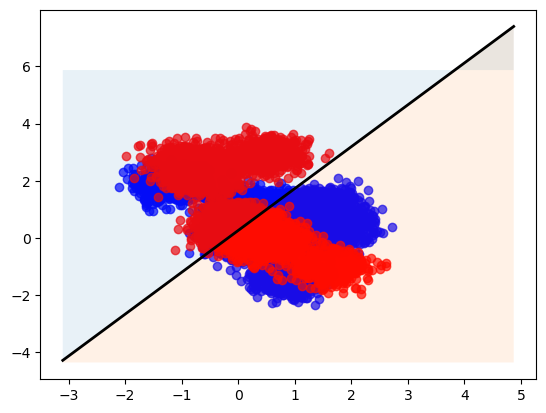

In [24]:
xaug=np.hstack((np.ones((x.shape[0],1)),x))                           ##

w=np.linalg.inv(xaug.T@xaug)@(xaug.T@y)  
score=xaug@w

y_pred=np.where(score>0,1,-1)                                          ##

tranining_error=np.mean(y_pred-y)
print(tranining_error)

x1_vals=np.linspace(x[:,0].min()-1,x[:,1].max()+1)
x2_vals=-(w[0]+w[1]*x1_vals)/w[2]                                           ## x1_vals

plt.scatter(x[y==1,0],x[y==1,1],color='blue',label='+1',alpha=0.7)
plt.scatter(x[y==-1,0],x[y==-1,1],color='red',label='-1',alpha=0.7)

plt.plot(x1_vals,x2_vals,color='black',linewidth=2,label='decision line')

plt.fill_between(x1_vals,x2_vals,x[:,1].max()+2,alpha=0.1)
plt.fill_between(x1_vals,x2_vals,x[:,1].min()-2,alpha=0.1)
